# 🧠 Foundational Understanding – Generative AI Workshop

Welcome to the first notebook of the Generative AI Engineer workshop!  
This notebook introduces the **core foundations** required to understand how modern Large Language Models (LLMs) work.

---

## 💡 What is a Large Language Model (LLM)?
A Large Language Model (LLM) is a type of AI that is capable of understanding and generating human-like text. These models are trained on vast amounts of text data from the internet, which enables them to perform various natural language tasks such as text generation, translation, summarization, and more. Some popular examples include GPT-3 and GPT-4 by OpenAI, BERT by Google, and T5.
What Makes LLMs Powerful?
LLMs are pre-trained on massive datasets, enabling them to generate coherent and contextually relevant text.
They learn to predict the next word in a sentence by processing patterns in the data they’ve seen.
Transfer learning allows them to be fine-tuned for specific tasks, like writing essays, answering questions, or generating creative content.

---

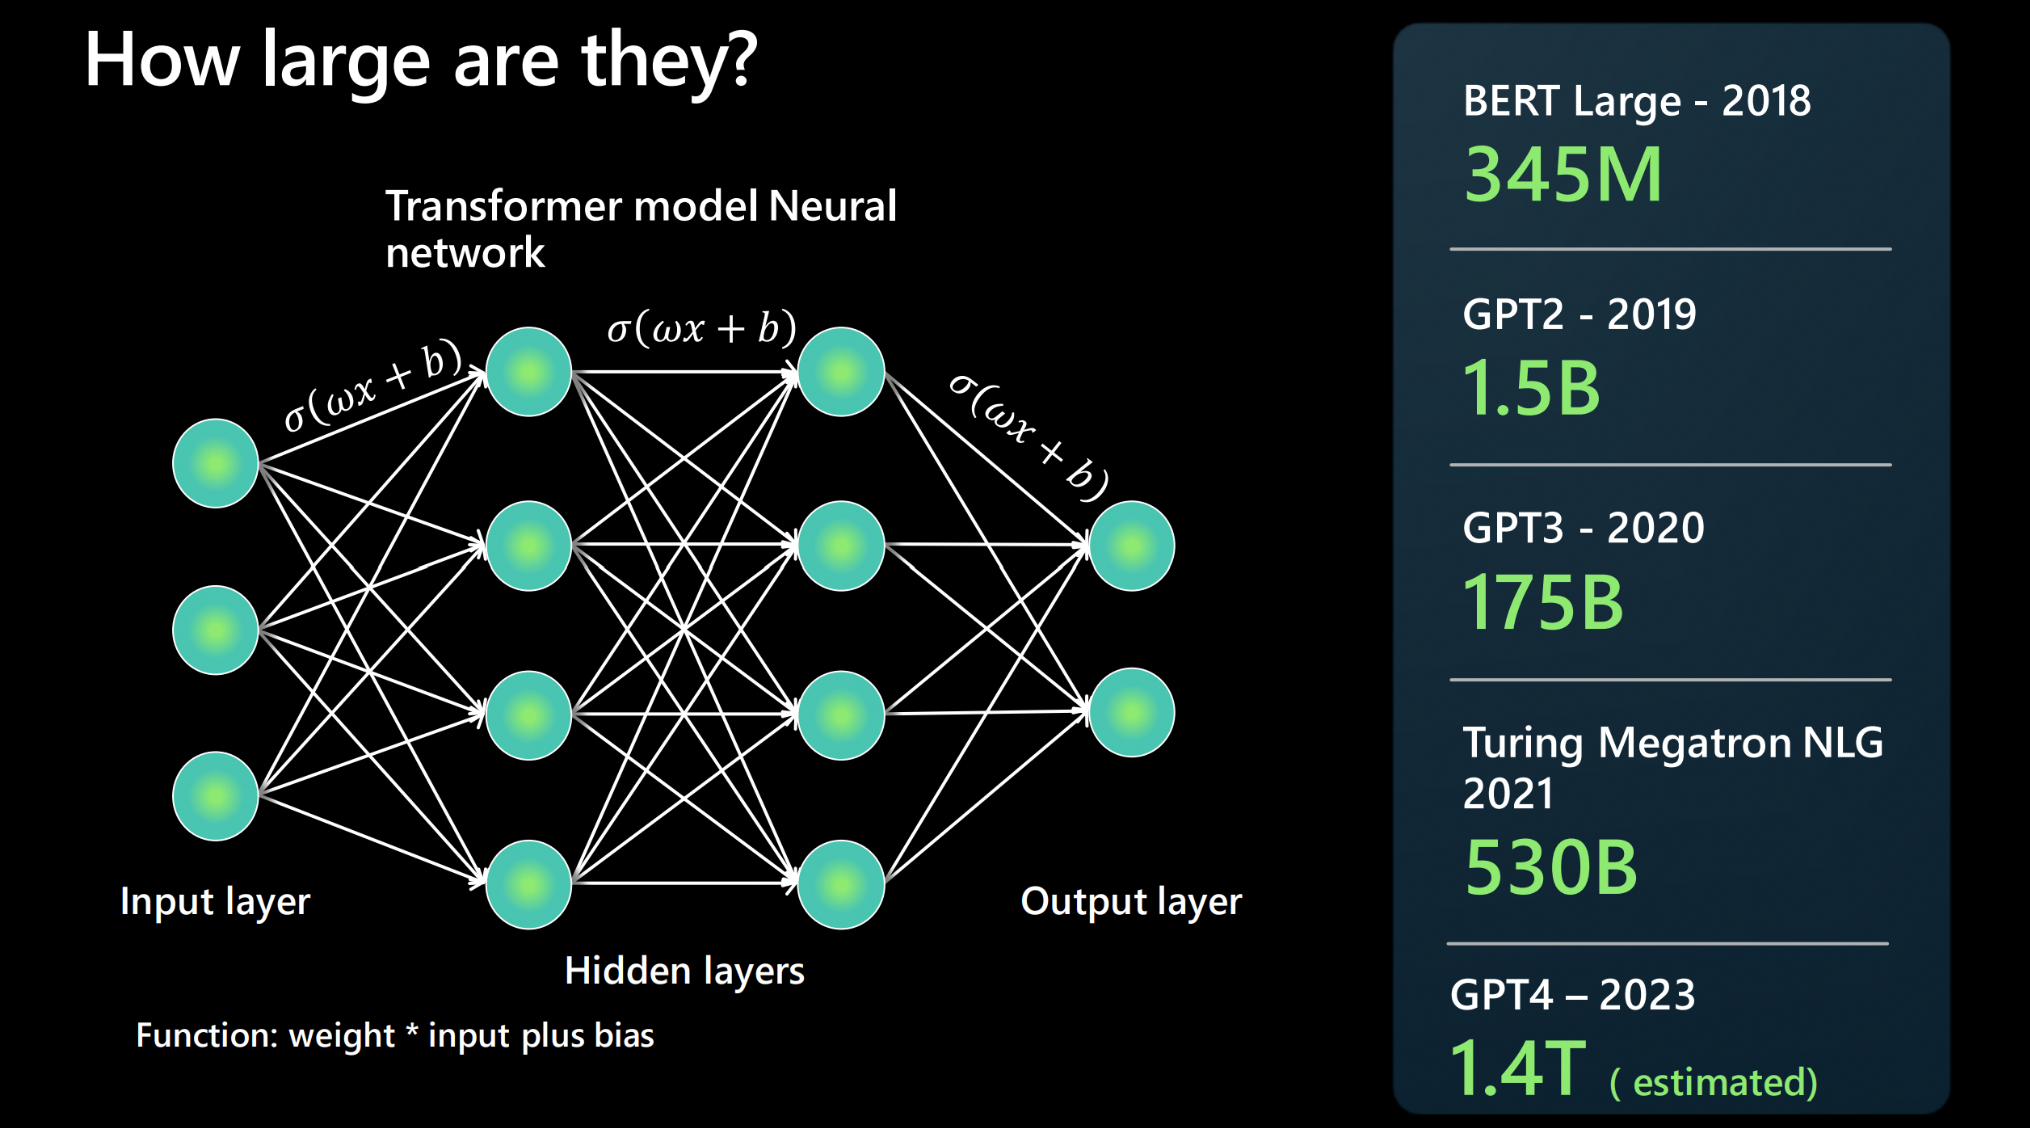

In [3]:
from IPython.display import Image

Image(filename='data/llm.png')

### *https://microsoft.github.io/Workshop-Interact-with-OpenAI-models/llms/*


## 🔍 How Are LLMs Trained?

Training a **Large Language Model (LLM)** involves two key stages:

### 🏋️‍♂️ 1. Pre-training

- The model is trained on a **large corpus of text** (books, websites, Wikipedia, news articles, etc.).
- The goal is to **learn language patterns, grammar, context, and semantics**.
- It uses the **transformer architecture**, which allows the model to:
  - Process the **entire input** at once (not word-by-word like older models).
  - Use **self-attention** to understand relationships between all words in a sentence.
- During pre-training, the model learns by predicting the **next word** in a sentence.

🧠 Example task during pre-training:
> Input: "The capital of France is"  
> Target: "Paris"

### 🛠️ 2. Fine-tuning

- After pre-training, the model is **adapted to specific tasks** by training on a **smaller, task-specific dataset**.
- This step makes the model **more accurate** for use cases like:
  - Customer support
  - Medical question answering
  - Legal document analysis
- Fine-tuning requires fewer resources than full training and helps **specialize** the model.

🧠 Example:
> Fine-tuning GPT on a medical Q&A dataset helps it answer health-related questions more reliably.

---

✅ **Summary:**
- **Pre-training** = Learn general language knowledge from a wide range of sources.
- **Fine-tuning** = Teach the model a specific skill or domain.

---
## Learning Objectives
- Understand the transformer architecture and self-attention mechanism
- Learn tokenization and embeddings
- Differentiate between generative and extractive models
- Explore sampling strategies (temperature, top-k, top-p)

## 1. Tokenization and Embeddings

Before text enters an LLM, it's **tokenized** into smaller units and converted into vectors.


### Simple Tokenization Example in Python

In [15]:
# Tokenization example: split a sentence into words (tokens)
text = "Generative AI creates new content from data."
tokens = text.split()  # simple whitespace tokenizer
print(tokens)  # ['Generative', 'AI', 'creates', 'new', 'content', 'from', 'data.']


['Generative', 'AI', 'creates', 'new', 'content', 'from', 'data.']


### Tokenization using Hugging Face tokenizer

Putting It Together: Using a Pre-trained Tokenizer (from Hugging Face)

In [16]:
# Example: Tokenize text using Hugging Face tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
text = "Hello Generative AI!"
tokens = tokenizer.tokenize(text)  # Convert text to tokens
print(tokens)  # Display tokenized words/subwords


['Hello', 'ĠGener', 'ative', 'ĠAI', '!']


### Basic Embedding Concept Example

In [17]:
# Example: Mapping tokens to vectors (simple one-hot encoding for demo)
vocab = ['Generative', 'AI', 'creates', 'new', 'content', 'from', 'data']
token = 'AI'
one_hot_vector = [1 if word == token else 0 for word in vocab]
print(one_hot_vector)  # [0, 1, 0, 0, 0, 0, 0]


[0, 1, 0, 0, 0, 0, 0]


### Convert tokens into numerical IDs (ready for model input)

In [18]:

token_ids = tokenizer.encode(text, return_tensors="pt")
print(token_ids)  # Tensor of token IDs


tensor([[15496,  2980,   876,  9552,     0]])


## 2. Transformer Architecture (Self-Attention)

Transformers are the backbone of modern LLMs.  
The key idea: **self-attention** lets each token "look at" every other token to understand context.

**Key Concept:**
- Each word gets converted into a **vector (embedding)**  
- Attention weights determine how much focus each token gives to others  


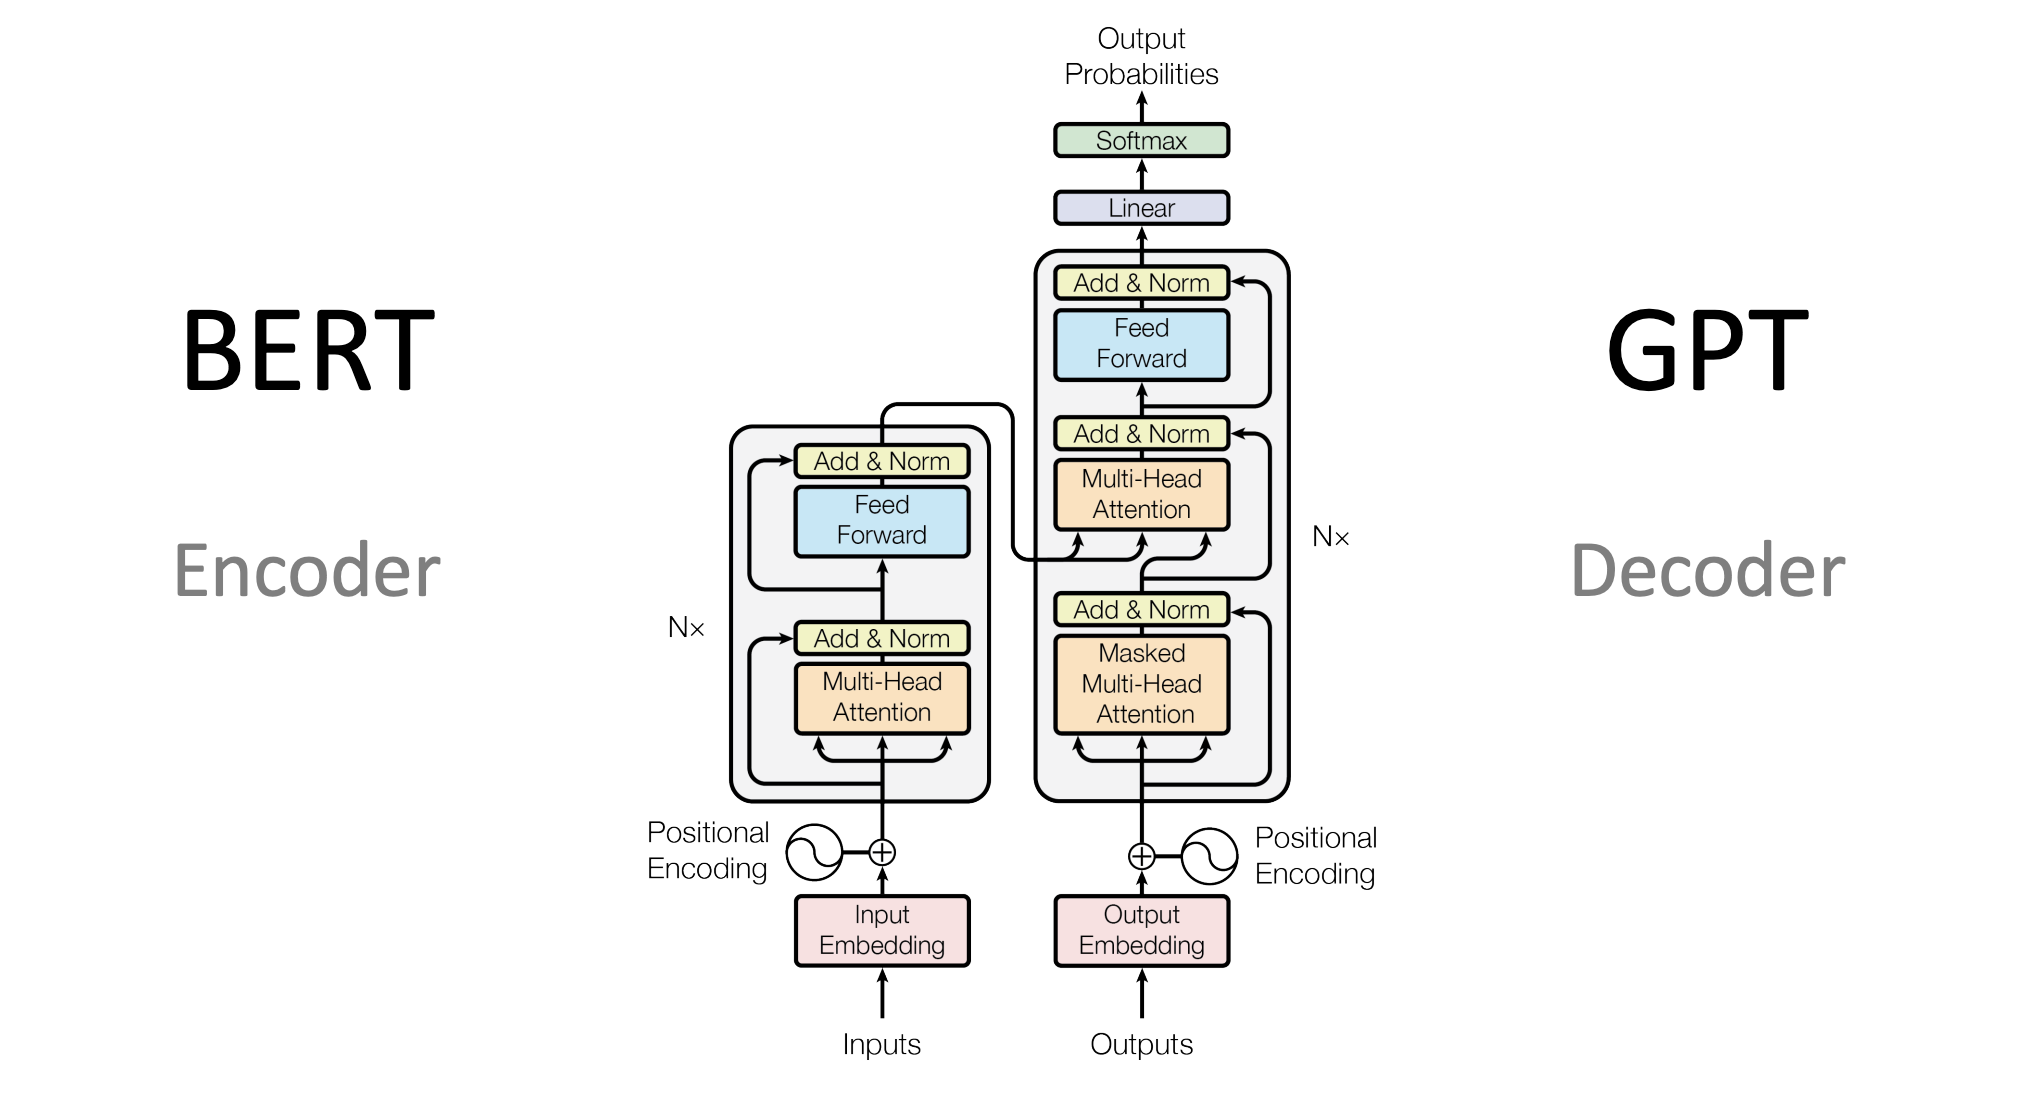

In [1]:
from IPython.display import Image

Image(filename='data/transformers.png')


---

### 2.1 Why Transformers? 🤔
- RNNs are sequential and struggle with long-range dependencies.
- CNNs capture local patterns but not global context easily.
- Transformers connect any two positions directly via attention and train in parallel → faster and better with long context.

---

### 2.2 The Big Picture 🧠
- Stack of N layers; each layer = Multi-Head Self-Attention (MHSA) + Feed-Forward Network (FFN), with residuals and layer norm.
- Workflow:
  1) Token embeddings + positional info
  2) Repeated blocks of [Self-Attention → FFN]
  3) Contextualized outputs for tasks (classification or generation)

---

### 2.3 Self-Attention (core mechanism) 🎯
- Each token forms three vectors:
  - Query (Q): what it seeks
  - Key (K): what it offers
  - Value (V): the information carried
- Attention scores = similarity(Q, K) across tokens → softmax to get weights → weighted sum of V produces a new representation per token.
- Intuition: For “bank,” attention looks to words like “river” vs. “money” to resolve meaning.

---

### 2.4 Multi-Head Attention (MHA) 👥
- Multiple attention “heads” run in parallel.
- Each head can focus on different patterns (syntax, long-range links, coreference).
- Outputs from heads are concatenated and mixed to form richer representations.

---

### 2.5 Positional Information 📍
- Attention alone ignores order.
- Add positional encodings/embeddings (absolute or relative) so the model knows token positions and distances.

---

### 2.6 Encoder vs. Decoder vs. Encoder-Decoder 🧩
- Encoder-only (e.g., BERT): bidirectional attention over the input → great for understanding tasks.
- Decoder-only (e.g., GPT): causal/masked attention (only looks left) → great for generation.
- Encoder-Decoder (e.g., original Transformer for translation): encoder builds source representation; decoder attends to encoder outputs plus previous generated tokens.

---
https://arxiv.org/abs/1706.03762

https://en.wikipedia.org/wiki/Attention_Is_All_You_Need

https://heidloff.net/article/foundation-models-transformers-bert-and-gpt/

In [9]:
# Example: Calculate attention weights between tokens using dot product
import torch
import torch.nn.functional as F

tokens = torch.rand(3, 4)  # Simulated token embeddings (3 tokens, 4 dimensions each)
scores = torch.matmul(tokens, tokens.T)  # Compute similarity between tokens
attention = F.softmax(scores, dim=-1)    # Normalize into probabilities
print(attention)  # Attention weights between tokens


tensor([[0.4688, 0.2302, 0.3010],
        [0.2927, 0.3721, 0.3353],
        [0.2385, 0.2089, 0.5526]])


💡 **Pro Tip:** Higher attention scores mean stronger contextual relationships between tokens.


## 3. Sampling Strategies

Sampling controls **creativity vs determinism** in generation.

- **Temperature:** Higher → more random  
- **Top-k:** Only pick from top-k probable tokens  
- **Top-p (nucleus):** Pick tokens until cumulative probability ≥ p  


### Sampling Strategies — One Simple Example 🍎

Prompt: “Write a creative sentence about an apple.”

The model has a list of next-word options with probabilities (e.g., “red”, “sweet”, “quantum”, “galaxy”, etc.). We’ll see how different settings change the sentence.

### 1) Temperature 🌡️
- Low Temperature (0.3): The model sticks to the safest words.
  - Output: “The apple is red and sweet.”
- High Temperature (1.2): The model takes more risks and explores unusual words.
  - Output: “The apple hums with sunrise sweetness, crisp as morning light.”

What changed? Higher temperature makes it more adventurous and poetic.

---

### 2) Top-k 🔢
- Top-k = 20: Only picks from the 20 most likely words.
  - Output: “The apple tastes fresh and crisp.”
- Top-k = 100: Picks from a larger set, including rarer words.
  - Output: “The apple tastes crisp, whispering hints of autumn orchards.”

What changed? Larger k allows more variety and imagery.

---

### 3) Top-p (Nucleus) 🌐
- Top-p = 0.85: Uses a small, safe set of words whose probabilities add to 85%.
  - Output: “The apple is crisp and juicy.”
- Top-p = 0.97: Uses a broader, more creative set.
  - Output: “The apple crackles with juice, a pocket of bright afternoon.”

What changed? Higher p lets in more colorful or unusual choices, but still adapts to the model’s confidence.

---

### Quick takeaway ✅
- Want safe and factual? Lower Temperature, smaller k, or lower p.
- Want creative and surprising? Higher Temperature, larger k, or higher p.
- Usually use Temperature + Top-p (pick one truncation method: Top-p or Top-k).

💡 **Pro Tip:** For more factual answers, use a lower temperature (e.g., 0.2–0.5).


## 🏁 Wrap-Up

In this notebook, you learned:
- How transformers process text using attention
- Tokenization and embeddings workflow
- Difference between generative and extractive models
- How sampling affects output creativity

## **Next Notebook → Prompt Engineering 🧰**
